# 2(b)

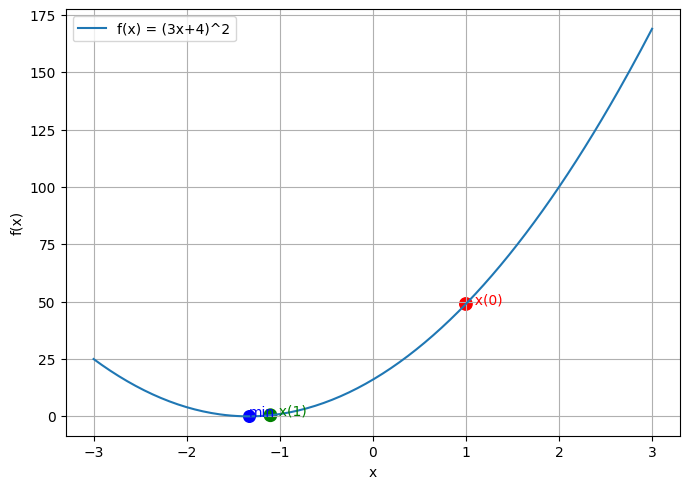

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Function f(x)
def f(x):
    return (3*x + 4)**2

# Derivative f'(x)
def fp(x):
    return 18*x + 24

# Gradient descent example step
eta = 0.05
x0 = 1.0
x1 = x0 - eta * fp(x0)

# Plot
xs = np.linspace(-3, 3, 200)
ys = f(xs)

plt.figure(figsize=(7,5))
plt.plot(xs, ys, label='f(x) = (3x+4)^2')
plt.scatter([x0, x1], [f(x0), f(x1)], color=['red','green'], s=80)
plt.text(x0, f(x0), '  x(0)', color='red')
plt.text(x1, f(x1), '  x(1)', color='green')

# Mark the minimum
xmin = -4/3
plt.scatter([xmin], [f(xmin)], color='blue', s=70)
plt.text(xmin, f(xmin), 'min', color='blue')

plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# 2(d)

In [2]:
def gradient_descent(f, df, x0, step_size_fn, max_iter):
    """
    Performs gradient descent on the given function f, with its gradient df.

    :param f: A function whose input is an x (column vector) and returns a scalar.
    :param df: A function whose input is an x (column vector) and returns
               a column vector: the gradient of f at x.
    :param x0: Initial value of x (column vector).
    :param step_size_fn: Function taking iteration index i and returning a step size.
    :param max_iter: Number of iterations to perform.

    :return x:  value at the final step
    :return fs: list of f(x) values for all iterations (including f(x0))
    :return xs: list of x values for all iterations (including x0)
    """

    # Make a (float) copy of the initial point
    x = x0.astype(float).copy()

    # Store function values and iterates
    fs = [float(f(x))]
    xs = [x.copy()]

    # Gradient descent loop
    for i in range(max_iter):
        step_size = step_size_fn(i)     # scalar α_i
        grad = df(x)                    # same shape as x (column vector)

        # Update rule: x_{i+1} = x_i - α_i * ∇f(x_i)
        x = x - step_size * grad

        # Record new point and function value
        fs.append(float(f(x)))
        xs.append(x.copy())

    return x, fs, xs


In [3]:
import numpy as np

# Our test function from 2(c): f(x) = (3x + 4)^2, with x as a 1D column vector
def f1(x):
    return float((3 * x[0, 0] + 4) ** 2)

def df1(x):
    # derivative: f'(x) = 18x + 24, but returned as a column vector
    return np.array([[18 * x[0, 0] + 24]])

# Initial point x0 as a column vector
x0 = np.array([[0.0]])

# Simple constant step size
step_size_fn = lambda i: 0.01

# Run gradient descent
last_x, fs, xs = gradient_descent(f1, df1, x0, step_size_fn, max_iter=50)

print("Final x:", last_x)
print("Final f(x):", fs[-1])


Final x: [[-1.33326793]]
Final f(x): 3.850394435417594e-08


# 2(e)(i)

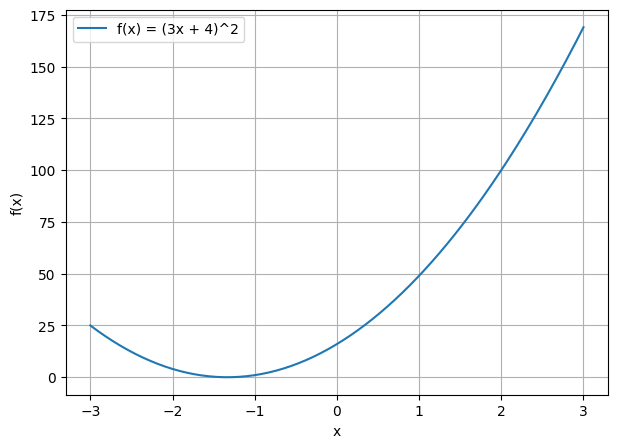

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# f(x) from part (c)
def f1(x):
    return float((3 * x + 4)**2)

# (i) Plot the function f(x) = (3x + 4)^2

# Create a range of x values
xs = np.linspace(-3, 3, 200)

# Evaluate the function on this range
ys = (3 * xs + 4)**2

# Plot the function
plt.figure(figsize=(7,5))
plt.plot(xs, ys, label="f(x) = (3x + 4)^2")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()


# 2(e)(ii)

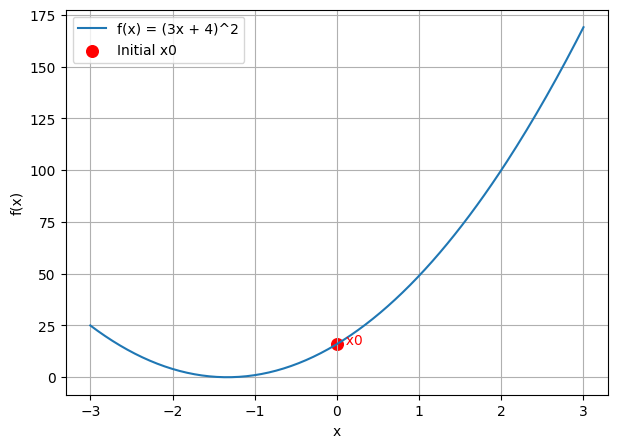

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# f(x) from part (c)
def f1(x):
    return float((3 * x + 4)**2)

# ----- (ii) Plot the initial value x0 on the same function plot -----

# Create the function curve again
xs = np.linspace(-3, 3, 200)
ys = (3 * xs + 4)**2

plt.figure(figsize=(7,5))
plt.plot(xs, ys, label="f(x) = (3x + 4)^2")

# Initial point x0 (example: x0 = np.array([[0.0]]))
x0 = np.array([[0.0]])
x0_value = float(0.0)
y0_value = f1(x0_value)

# Plot the initial point
plt.scatter([x0_value], [y0_value], color='red', s=70, label="Initial x0")
plt.text(x0_value, y0_value, "  x0", color='red')

plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()


# 2(e)(iii)

In [9]:
import numpy as np

# Generic gradient descent
def gradient_descent(f, df, x0, step_size_fn, max_iter):
    x = x0.copy()
    fs = [f(x)]
    xs = [x.copy()]

    for i in range(max_iter):
        x = x - step_size_fn(i) * df(x)
        fs.append(f(x))
        xs.append(x.copy())

    return x, fs, xs


# Our test function and derivative from (c)
def f1_scalar(x):
    return float((3 * x + 4) ** 2)

def df1_scalar(x):
    return float(18 * x + 24)


# Wrap them to work with column vectors
def f1(x):
    return f1_scalar(x[0, 0])

def df1(x):
    return np.array([[df1_scalar(x[0, 0])]])


if __name__ == "__main__":
    # Initial guess x0 as column vector
    x0 = np.array([[0.0]])  

    # Different constant step sizes to try
    step_sizes = [1.0, 0.5, 0.1, 0.01, 0.001, 0.0001]

    for alpha in step_sizes:
        step_size_fn = lambda i, a=alpha: a

        x_final, fs, xs = gradient_descent(f1, df1, x0, step_size_fn, max_iter=50)

        print(f"\nStep size α = {alpha}")
        print("  Final x:", x_final[0, 0])
        print("  Final f(x):", fs[-1])



Step size α = 1.0
  Final x: 4.440018764286241e+61
  Final f(x): 1.774238996449253e+124

Step size α = 0.5
  Final x: 1.9029969236079464e+45
  Final f(x): 3.259257562135178e+91

Step size α = 0.1
  Final x: -1.333314303364097
  Final f(x): 3.259257562200121e-09

Step size α = 0.01
  Final x: -1.3332679252601363
  Final f(x): 3.850394435417594e-08

Step size α = 0.001
  Final x: -0.7956666502176899
  Final f(x): 2.6017691591932004

Step size α = 0.0001
  Final x: -0.11485723880494582
  Final f(x): 13.362155936434368


# 2(e)(iv)

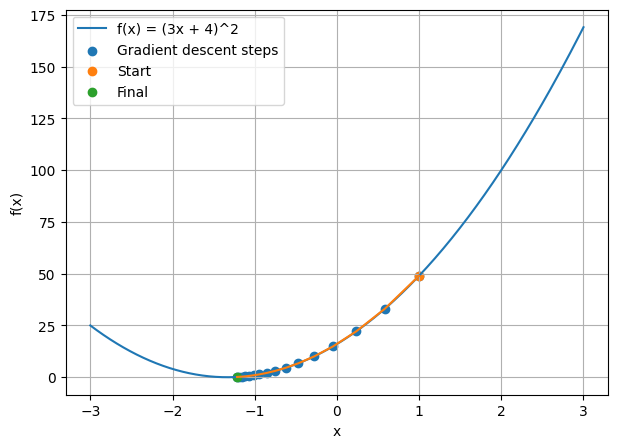

Final x = -1.2144325896335002
Final f(x) = 0.12723648167136067


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent(f, df, x0, step_size_fn, max_iter):
    x = x0.copy()
    fs = [f(x)]
    xs = [x.copy()]

    for i in range(max_iter):
        x = x - step_size_fn(i) * df(x)
        fs.append(f(x))
        xs.append(x.copy())

    return x, fs, xs


def f1_scalar(x):
    return float((3 * x + 4) ** 2)

def df1_scalar(x):
    return float(18 * x + 24)

def f1(x):
    return f1_scalar(x[0, 0])

def df1(x):
    return np.array([[df1_scalar(x[0, 0])]])


if __name__ == "__main__":
    x0 = np.array([[1.0]])
    step_size_fn = lambda i: 0.01
    max_iter = 15

    x_final, fs, xs = gradient_descent(f1, df1, x0, step_size_fn, max_iter)

    # Plot the function
    x_plot = np.linspace(-3, 3, 300)
    y_plot = [f1_scalar(x) for x in x_plot]

    plt.figure(figsize=(7, 5))
    plt.plot(x_plot, y_plot, label="f(x) = (3x + 4)^2")

    # Extract gradient descent points
    x_steps = [x[0, 0] for x in xs]
    y_steps = fs

    # Plot all GD steps
    plt.scatter(x_steps, y_steps, label="Gradient descent steps")
    plt.plot(x_steps, y_steps)

    # Highlight initial and final points
    plt.scatter(x_steps[0], y_steps[0], label="Start")
    plt.scatter(x_steps[-1], y_steps[-1], label="Final")

    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Final x =", x_final[0, 0])
    print("Final f(x) =", fs[-1])
